# Analysis for Hawkesbury-Nepean Valley hydrology example (Section 4.1)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scores.probability import interval_tw_crps_for_ensemble
from scores.stats.statistical_tests import diebold_mariano
from scores.continuous import tw_quantile_score

<details>
<summary>
    <b>Package details</b>
    
Click here to see output of `!pip list`. This will let you see the versions of the packages used at the time when  the notebook was archived.</summary>


Package                           Version
--------------------------------- -----------
alabaster                         0.7.16
alembic                           1.8.1
annotated-types                   0.6.0
anyio                             4.2.0
argon2-cffi                       21.3.0
argon2-cffi-bindings              21.2.0
asciitree                         0.3.3
astroid                           3.2.4
asttokens                         2.0.5
async-generator                   1.10
async-lru                         2.0.4
attrs                             23.1.0
Babel                             2.11.0
bandit                            1.7.9
beautifulsoup4                    4.12.3
black                             24.4.2
bleach                            4.1.0
blinker                           1.6.2
bokeh                             3.4.1
bom-jive                          1.24.5
Bottleneck                        1.3.7
branca                            0.6.0
Brotli                            1.0.9
cached-property                   1.5.2
cachetools                        5.3.3
Cartopy                           0.22.0
certifi                           2025.10.5
certipy                           0.1.3
cffi                              1.16.0
cfgv                              3.4.0
cftime                            1.6.2
charset-normalizer                3.3.2
click                             8.1.7
click-plugins                     1.1.1
cligj                             0.7.2
cloudpickle                       3.0.0
colorama                          0.4.6
comm                              0.2.1
commonmark                        0.9.1
contourpy                         1.2.0
coverage                          7.2.2
cryptography                      43.0.0
cx-Oracle                         8.3.0
cycler                            0.11.0
cytoolz                           0.12.2
dask                              2024.5.0
dask-expr                         1.1.0
debugpy                           1.6.7
decorator                         5.1.1
defusedxml                        0.7.1
dill                              0.3.8
distlib                           0.3.8
distributed                       2024.5.0
docopt                            0.6.2
docutils                          0.18.1
entrypoints                       0.4
eta_verification                  0.19.2
executing                         0.8.3
fasteners                         0.16.3
fastjsonschema                    2.16.2
filelock                          3.13.1
fiona                             1.9.6
flake8                            7.0.0
flexcache                         0.3
flexparser                        0.4
folium                            0.14.0
fonttools                         4.51.0
fsspec                            2024.6.1
future                            0.18.3
GDAL                              3.9.2
GeoAlchemy2                       0.15.2
geopandas                         0.14.2
gitdb                             4.0.7
GitPython                         3.1.43
greenlet                          3.0.1
h5py                              3.11.0
HeapDict                          1.0.1
identify                          2.5.5
idna                              3.7
imagesize                         1.4.1
importlib-metadata                7.0.1
iniconfig                         1.1.1
ipykernel                         6.28.0
ipython                           8.25.0
ipython-genutils                  0.2.0
ipywidgets                        8.1.2
isodate                           0.6.1
isort                             5.13.2
jedi                              0.19.1
Jinja2                            3.1.4
jive_adam                         0.4.1
jive_aifs_warnings                0.3.0
jive_ehf                          0.9.1
jive_gfe                          0.12.8
joblib                            1.4.2
json5                             0.9.6
jsonschema                        4.19.2
jsonschema-specifications         2023.7.1
jupyter                           1.0.0
jupyter_client                    7.4.9
jupyter-console                   6.6.3
jupyter-contrib-core              0.4.0
jupyter-contrib-nbextensions      0.7.0
jupyter_core                      5.7.2
jupyter-events                    0.10.0
jupyter-highlight-selected-word   0.2.0
jupyter-kernel-gateway            2.5.0
jupyter-latex-envs                1.4.6
jupyter-lsp                       2.2.0
jupyter-nbextensions-configurator 0.6.1
jupyter_server                    2.14.1
jupyter_server_terminals          0.4.4
jupyter-telemetry                 0.1.0
jupyterhub                        2.3.1
jupyterhub_saml2                  0.9.0
jupyterlab                        4.0.11
jupyterlab_code_formatter         3.0.2
jupyterlab_execute_time           3.1.2
jupyterlab-pygments               0.1.2
jupyterlab_server                 2.25.1
jupyterlab-widgets                3.0.10
kaleido                           0.2.1
kiwisolver                        1.4.4
llvmlite                          0.44.0
lmdb                              1.4.1
locket                            1.0.0
lxml                              5.3.0
lz4                               4.3.2
Mako                              1.2.3
mapclassify                       2.5.0
markdown-it-py                    3.0.0
MarkupSafe                        2.1.3
matplotlib                        3.9.2
matplotlib-inline                 0.1.6
mccabe                            0.7.0
mdit-py-plugins                   0.4.1
mdurl                             0.1.0
memory-profiler                   0.61.0
MetPy                             1.6.3
mistune                           2.0.4
mkl_fft                           1.3.10
mkl_random                        1.2.7
mkl-service                       2.4.0
msgpack                           1.0.3
mypy-extensions                   1.0.0
myst-parser                       3.0.1
nbclassic                         1.1.0
nbclient                          0.8.0
nbconvert                         7.10.0
nbformat                          5.9.2
nest-asyncio                      1.6.0
netCDF4                           1.7.1
networkx                          3.3
nodeenv                           1.7.0
notebook                          6.5.7
notebook_shim                     0.2.3
numba                             0.61.2
numcodecs                         0.12.1
numexpr                           2.8.7
numpy                             1.26.4
oauthlib                          3.2.2
oracledb                          2.1.1
overrides                         7.4.0
packaging                         24.1
pamela                            1.0.0
pandas                            2.1.4
pandocfilters                     1.5.0
parso                             0.8.3
partd                             1.4.1
pathspec                          0.10.3
patsy                             0.5.6
pbr                               5.6.0
pep8                              1.7.1
pexpect                           4.8.0
pillow                            10.4.0
Pint                              0.24.4
pip                               24.2
platformdirs                      3.10.0
plotly                            5.22.0
pluggy                            1.0.0
ply                               3.11
pooch                             1.8.2
pre_commit                        3.8.0
prometheus-client                 0.14.1
prompt-toolkit                    3.0.43
psutil                            5.9.0
psycopg2                          2.9.9
ptyprocess                        0.7.0
pure-eval                         0.2.2
pyarrow                           17.0.0
pycodestyle                       2.11.1
pycparser                         2.21
pycurl                            7.45.3
pydantic                          2.8.2
pydantic_core                     2.20.1
pyflakes                          3.2.0
Pygments                          2.15.1
PyJWT                             2.8.0
pylint                            3.2.2
pyOpenSSL                         24.2.1
pyparsing                         3.1.2
pyproj                            3.6.1
PyQt5                             5.15.10
PyQt5-sip                         12.13.0
pyshp                             2.3.1
PySocks                           1.7.1
pytest                            7.4.4
pytest-cov                        4.1.0
pytest-runner                     6.0.0
python-dateutil                   2.9.0.post0
python-json-logger                2.0.7
python3-saml                      1.9.0
pytz                              2024.1
PyYAML                            6.0.1
pyzmq                             25.1.2
qtconsole                         5.5.1
QtPy                              2.4.1
recommonmark                      0.6.0
referencing                       0.30.2
requests                          2.32.3
rfc3339-validator                 0.1.4
rfc3986-validator                 0.1.1
rich                              10.16.2
rpds-py                           0.10.6
Rtree                             1.0.1
ruamel.yaml                       0.18.6
ruamel.yaml.clib                  0.2.8
scikit-learn                      1.5.1
scipy                             1.13.1
scores                            2.2.0
scoringrules                      0.8.0
seaborn                           0.13.2
Send2Trash                        1.8.2
setuptools                        72.1.0
shapely                           2.0.6
sip                               6.7.12
six                               1.16.0
smmap                             4.0.0
sniffio                           1.3.0
snowballstemmer                   2.2.0
sortedcontainers                  2.4.0
soupsieve                         2.5
Sphinx                            7.3.7
sphinx_rtd_theme                  2.0.0
sphinxcontrib-applehelp           1.0.2
sphinxcontrib-devhelp             1.0.2
sphinxcontrib-htmlhelp            2.0.0
sphinxcontrib-jquery              4.1
sphinxcontrib-jsmath              1.0.1
sphinxcontrib-qthelp              1.0.3
sphinxcontrib-serializinghtml     1.1.10
SQLAlchemy                        1.4.49
stack-data                        0.2.0
statsmodels                       0.14.2
stevedore                         5.3.0
tblib                             1.7.0
tenacity                          8.2.3
terminado                         0.17.1
threadpoolctl                     3.5.0
tinycss2                          1.2.1
toml                              0.10.2
tomli                             2.0.1
tomlkit                           0.11.1
toolz                             0.12.0
tornado                           6.4.1
traitlets                         5.14.3
typing_extensions                 4.11.0
tzdata                            2023.3
ukkonen                           1.0.1
unicodedata2                      15.1.0
urllib3                           2.2.2
virtualenv                        20.26.1
wcwidth                           0.2.5
webencodings                      0.5.1
websocket-client                  1.8.0
wheel                             0.43.0
widgetsnbextension                4.0.10
xarray                            2024.7.0
xgboost                           2.1.1
xmlsec                            1.3.14
xmltodict                         0.13.0
xyzservices                       2022.9.0
zarr                              2.18.2
zict                              3.0.0
zipp                              3.17.0
    
</details>

## Code for Figure 3

In [2]:
# open the timeseries data
timeseries_epsA = xr.open_dataarray('data/north_richmond_timeseries_epsA.nc')
timeseries_epsB = xr.open_dataarray('data/north_richmond_timeseries_epsB.nc')
timeseries_obs = xr.open_dataarray('data/north_richmond_timeseries_obs.nc')

# convert the time dimension to hours since 2024-06-06

start_time = timeseries_obs['time'].values[0]

timeseries_obs = timeseries_obs.assign_coords(
    time=(timeseries_obs['time'] - start_time) / np.timedelta64(1, 'h')
)

timeseries_epsA = timeseries_epsA.assign_coords(
    time=(timeseries_epsA['time'] - start_time) / np.timedelta64(1, 'h')
)

timeseries_epsB = timeseries_epsB.assign_coords(
    time=(timeseries_epsB['time'] - start_time) / np.timedelta64(1, 'h')
)

ERROR 1: PROJ: proj_create_from_database: Open of /work/autogfe/miniconda3/envs/jupyterhub/share/proj failed


In [3]:
# critical flood heights for North Richmond
MINOR = 3.8
MODERATE = 7.9
MAJOR = 10.5

In [4]:
def ecdf_for_threshold_exceedance(fcst, threshold):
    """
    Calculates, for each time coordinate, the proportion
    of ensemble members that have exceeded the threshold
    up till that time.
    
    Args:
        fcst: xarray data array of forecast values, including dimensions
            'time' and 'realization'.
        threshold: the threshold to exceed
        
    Returns:
        xarray data array of proportions, with 'realization' dimension collapsed.
    """
    # the number of non-NaN ensemble members per time step
    n_members = fcst.count('realization')
    
    # the cumulative maximum of forecast values along the time dimension
    cummax = fcst.cumulative('time').max()
    
    # the proportion of ensemble members having exceeded the threshold
    result = (cummax > threshold).sum('realization') / n_members
    
    return result



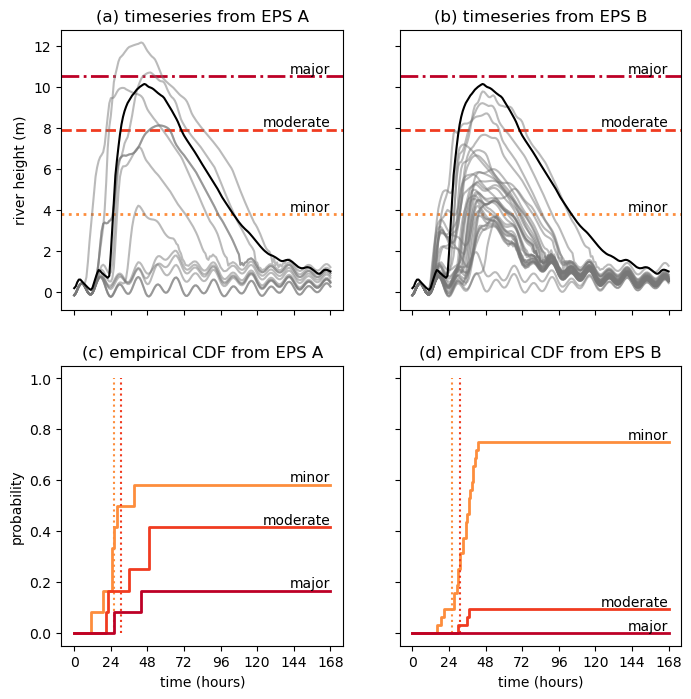

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharey='row', sharex=True, figsize=(8, 8))

timeseries_fcsts = [timeseries_epsA, timeseries_epsB]
levels = [MINOR, MODERATE, MAJOR]

level_dash = ['dotted', 'dashed', 'dashdot']
level_colour = ['#fd8d3c','#f03b20','#bd0026']
level_labels = ['minor', 'moderate', 'major']

xpos_label = 168

for idx_fcst in range(2):
    
    for idx_level in range(3):    
        # warning levels on hydrographs
        axes[0,idx_fcst].axhline(
            y=levels[idx_level],
            color=level_colour[idx_level],
            linestyle=level_dash[idx_level],
            linewidth=2,
            label=level_labels[idx_level]
        )
    
    # get the timeseries forecast
    ts_fcst = timeseries_fcsts[idx_fcst]
    
    # plot the hydrograph for each ensemble member
    for idx_member in range(len(ts_fcst['realization'])):
        member = ts_fcst.isel(realization=idx_member)
        axes[0,idx_fcst].plot(
            member['time'].values,
            member.values.flatten(),
            color='#777777',
            alpha=0.5,
        )
        
    # plot the hydrograph of observations
    axes[0,idx_fcst].plot(
        timeseries_obs['time'].values,
        timeseries_obs.values,
        'k-'
    )
    
    
    for idx_level in range(3):
        
        # plot the flood level labels on the top row
        axes[0,idx_fcst].text(
            xpos_label, levels[idx_level], level_labels[idx_level], ha='right', va='bottom', fontsize=10
        )
        
        # ecdf for first passage time for each warning level threshold
        this_ecdf = ecdf_for_threshold_exceedance(ts_fcst, levels[idx_level])
        axes[1,idx_fcst].step(
            this_ecdf['time'].values,
            this_ecdf.values.flatten(),
            color=level_colour[idx_level],
            linewidth=2,
        )
        
        # plot the observed first passage time
        the_fpt_obs = float(
            timeseries_obs['time'].where(timeseries_obs > levels[idx_level]).min()
        )
        if not np.isnan(the_fpt_obs):
            axes[1,idx_fcst].plot(
                [the_fpt_obs, the_fpt_obs],
                [0, 1],
                color=level_colour[idx_level],
                linestyle='dotted',
                linewidth=1.5,
            )
            
        # label the flood level for the ECDF plot
        axes[1,idx_fcst].text(
            xpos_label, 
            float(this_ecdf.max()),
            level_labels[idx_level],
            ha='right',
            va='bottom',
            fontsize=10
        )
        

    # add ticks and x axis labels
    axes[0,idx_fcst].set_xticks([0, 24, 48, 72, 96, 120, 144, 168]) # Set specific tick locations
    axes[1,idx_fcst].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1]) # Set specific tick locations
    axes[1,idx_fcst].set_xlabel("time (hours)")
    

    
axes[0,0].set_ylabel("river height (m)")
axes[1,0].set_ylabel("probability")

# plot substitles
axes[0,0].set_title('(a) timeseries from EPS A')
axes[0,1].set_title('(b) timeseries from EPS B')
axes[1,0].set_title('(c) empirical CDF from EPS A')
axes[1,1].set_title('(d) empirical CDF from EPS B')
    
fig.show()

## Results for Table 6

In [6]:
fcst = xr.open_dataset('data/hnv_forecast_first_passage_time.nc')
fcst

<xarray.Dataset> Size: 8MB
Dimensions:          (analysis_time: 665, realization: 32, station_id: 8,
                      flood_threshold: 3)
Coordinates:
  * analysis_time    (analysis_time) datetime64[ns] 5kB 2024-05-09T02:00:00 ....
  * realization      (realization) int32 128B 0 1 2 3 4 5 ... 26 27 28 29 30 31
  * station_id       (station_id) <U7 224B 'H063280' 'H067093' ... 'H568154'
  * flood_threshold  (flood_threshold) <U14 168B 'MINOR_FLD_H' ... 'MAJOR_FLD_H'
Data variables:
    EPS_A            (analysis_time, realization, station_id, flood_threshold) float64 4MB ...
    EPS_B            (analysis_time, realization, station_id, flood_threshold) float64 4MB ...
Attributes:
    Note:     A value of 10e6 indicates that the flood threshold was not atta...

In [7]:
obs = xr.open_dataarray('data/hnv_observed_first_passage_time.nc')
obs

<xarray.DataArray 'time' (analysis_time: 665, station_id: 8, flood_threshold: 3)> Size: 128kB
[15960 values with dtype=float64]
Coordinates:
  * station_id       (station_id) <U7 224B 'H063280' 'H067093' ... 'H568154'
  * flood_threshold  (flood_threshold) <U14 168B 'MINOR_FLD_H' ... 'MAJOR_FLD_H'
  * analysis_time    (analysis_time) datetime64[ns] 5kB 2024-05-09T02:00:00 ....
Attributes:
    note:     if the evant did not occur after the analysis time within the o...

In [8]:
twcrps_scores = interval_tw_crps_for_ensemble(
    fcst, obs, 'realization', 0, 168, method='fair', reduce_dims=['station_id']
)
twcrps_scores

<xarray.Dataset> Size: 37kB
Dimensions:          (analysis_time: 665, flood_threshold: 3)
Coordinates:
  * analysis_time    (analysis_time) datetime64[ns] 5kB 2024-05-09T02:00:00 ....
  * flood_threshold  (flood_threshold) <U14 168B 'MINOR_FLD_H' ... 'MAJOR_FLD_H'
Data variables:
    EPS_A            (analysis_time, flood_threshold) float64 16kB 0.0 ... 0.0
    EPS_B            (analysis_time, flood_threshold) float64 16kB 0.0 ... 0.0

In [9]:
# results for Table 6
twcrps_scores.mean('analysis_time').to_dataframe().round(3)

,EPS_A,EPS_B
flood_threshold,,
MINOR_FLD_H,3.291,3.736
MODERATE_FLD_H,0.624,0.820
MAJOR_FLD_H,0.001,0.009


In [10]:
# calculate the corresponding p-values
twcrps_diff = twcrps_scores['EPS_A'] - twcrps_scores['EPS_B']
twcrps_diff = twcrps_diff.assign_coords(h=("flood_threshold", [1, 1, 1]))
dm = diebold_mariano(twcrps_diff, 'flood_threshold', 'h', confidence_level=0.9)
dm['confidence_gt_0'].to_dataframe('p_value').round(3)

,p_value
flood_threshold,
MINOR_FLD_H,0.031
MODERATE_FLD_H,0.020
MAJOR_FLD_H,0.008


## Results for IQR forecasts

In [11]:
# calculate the upper and lower quartiles
fcst_q25 = fcst.quantile(0.25, 'realization').drop_vars('quantile')
fcst_q75 = fcst.quantile(0.75, 'realization').drop_vars('quantile')

In [12]:
# calculate the threshold weighted interval scores
twis = tw_quantile_score(fcst_q25, obs, 0.25, [0,168], reduce_dims=['station_id'])
twis += tw_quantile_score(fcst_q75, obs, 0.75, [0,168], reduce_dims=['station_id'])
twis

<xarray.Dataset> Size: 37kB
Dimensions:          (analysis_time: 665, flood_threshold: 3)
Coordinates:
  * analysis_time    (analysis_time) datetime64[ns] 5kB 2024-05-09T02:00:00 ....
  * flood_threshold  (flood_threshold) <U14 168B 'MINOR_FLD_H' ... 'MAJOR_FLD_H'
Data variables:
    EPS_A            (analysis_time, flood_threshold) float64 16kB 0.0 ... 0.0
    EPS_B            (analysis_time, flood_threshold) float64 16kB 0.0 ... 0.0

In [13]:
twis.mean('analysis_time').to_dataframe().round(3)

,EPS_A,EPS_B
flood_threshold,,
MINOR_FLD_H,3.771,4.014
MODERATE_FLD_H,0.773,0.994
MAJOR_FLD_H,0.000,0.003


In [14]:
# p-values for above result
twis_diff = twis['EPS_A'] - twis['EPS_B']
twis_diff = twis_diff.assign_coords(h=("flood_threshold", [1, 1, 1]))
dm_twis = diebold_mariano(twis_diff, 'flood_threshold', 'h', confidence_level=0.9)
dm_twis['confidence_gt_0'].to_dataframe('p_value').round(3)

,p_value
flood_threshold,
MINOR_FLD_H,0.171
MODERATE_FLD_H,0.039
MAJOR_FLD_H,0.158
